# Lab | Statistical Story Dashboard

Numbers alone rarely convince anyone. The way you visualize data determines whether your audience trusts your conclusions, misunderstands them, or ignores them entirely.

In this lab you will:
1. **Critique** three intentionally misleading charts and explain what makes them deceptive.
2. **Redesign** each chart so the same data tells an accurate story.
3. **Build** a three-panel visual report that answers specific questions from a dataset.

Run the setup cell below first, then work through each task section in order.

## Setup

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

%matplotlib inline

## Dataset

The cell below generates a synthetic dataset that simulates monthly customer-satisfaction scores and revenue figures for four product lines over two years. It includes:

- **Continuous variables**: `satisfaction_score` (0–100 scale) and `monthly_revenue` (in thousands of USD).
- **Categorical groups**: four product lines (*Alpha*, *Beta*, *Gamma*, *Delta*).
- **Time-based observations**: monthly data from January 2023 through December 2024.

Run this cell to load the data into `df`.

In [4]:
np.random.seed(42)

months = pd.date_range("2023-01-01", "2024-12-01", freq="MS")
products = ["Alpha", "Beta", "Gamma", "Delta"]

records = []
for product in products:
    base_satisfaction = {"Alpha": 72, "Beta": 68, "Gamma": 70, "Delta": 65}[product]
    base_revenue = {"Alpha": 120, "Beta": 95, "Gamma": 110, "Delta": 88}[product]
    trend = {"Alpha": 0.4, "Beta": 0.1, "Gamma": -0.2, "Delta": 0.6}[product]

    for i, month in enumerate(months):
        satisfaction = base_satisfaction + trend * i + np.random.normal(0, 3)
        satisfaction = np.clip(satisfaction, 0, 100)

        seasonal = 8 * np.sin(2 * np.pi * (month.month - 1) / 12)
        revenue = base_revenue + trend * 2 * i + seasonal + np.random.normal(0, 6)

        records.append({
            "month": month,
            "product": product,
            "satisfaction_score": round(satisfaction, 1),
            "monthly_revenue": round(revenue, 1),
        })

df = pd.DataFrame(records)
print(f"Dataset shape: {df.shape}")
df.head(10)

Dataset shape: (96, 4)


,month,product,satisfaction_score,monthly_revenue
0,2023-01-01,Alpha,73.5,119.2
1,2023-02-01,Alpha,74.3,133.9
2,2023-03-01,Alpha,72.1,127.1
3,2023-04-01,Alpha,77.9,135.0
4,2023-05-01,Alpha,72.2,133.4
5,2023-06-01,Alpha,72.6,125.2
6,2023-07-01,Alpha,75.1,113.3
7,2023-08-01,Alpha,69.6,118.2
8,2023-09-01,Alpha,72.2,121.4
9,2023-10-01,Alpha,72.9,110.7


In [5]:
df.info()
print()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96 entries, 0 to 95
Data columns (total 4 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   month               96 non-null     datetime64[ns]
 1   product             96 non-null     object        
 2   satisfaction_score  96 non-null     float64       
 3   monthly_revenue     96 non-null     float64       
dtypes: datetime64[ns](1), float64(2), object(1)
memory usage: 3.1+ KB



,month,satisfaction_score,monthly_revenue
count,96,96.000000,96.000000
mean,2023-12-16 10:00:00,70.993750,108.755208
min,2023-01-01 00:00:00,60.600000,84.400000
25%,2023-06-23 12:00:00,67.875000,97.875000
50%,2023-12-16 12:00:00,70.150000,106.650000
75%,2024-06-08 12:00:00,74.325000,118.400000
max,2024-12-01 00:00:00,82.200000,151.100000
std,NaN,4.856029,14.668160


---

## Task 1: Chart Critique — Spot the Deception

The three charts below are **intentionally misleading**. For each one:

1. **Identify the deception technique** (e.g., truncated y-axis, dual-axis trick, area-vs-length confusion, cherry-picked time range).
2. **Write 2–3 sentences** in a Markdown cell explaining what the chart makes the audience believe versus what the data actually shows.
3. **Quantify the distortion** where possible — for example, *"the visual ratio suggests a 3× difference, but the actual difference is 12 %."*

**Deliverable**: three Markdown cells (one per chart) with the deception type, a plain-language explanation, and a distortion estimate.

### Misleading Chart 1 — Truncated Y-Axis

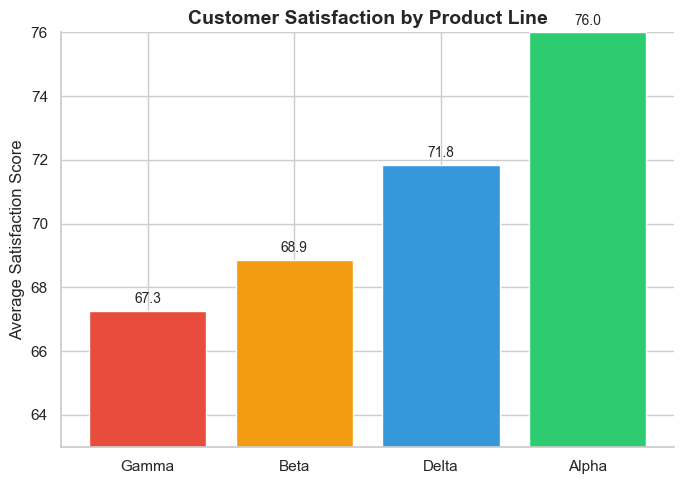

In [6]:
avg_sat = df.groupby("product")["satisfaction_score"].mean().sort_values()

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(avg_sat.index, avg_sat.values, color=["#e74c3c", "#f39c12", "#3498db", "#2ecc71"])
ax.set_ylim(63, 76)
ax.set_ylabel("Average Satisfaction Score")
ax.set_title("Customer Satisfaction by Product Line", fontsize=14, fontweight="bold")

for bar in bars:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.15,
            f"{bar.get_height():.1f}", ha="center", va="bottom", fontsize=10)

ax.yaxis.set_major_locator(ticker.MultipleLocator(2))
sns.despine()
plt.tight_layout()
plt.show()

**Your critique of Chart 1:**

*TODO: Write your analysis here — identify the deception, explain the misleading message, and quantify the distortion.*

**Explanation:**
The chart starts the Y-axis at 63 instead of zero, which exaggerates the difference between the “Delta” and “Alpha” products. This makes “Alpha” appear significantly larger than “Delta,” potentially leading viewers to believe that Alpha performs two to three times better. In reality, both values fall within a similar range (60–80), and the difference is relatively small.

**Distortion Estimate:**
Visually, the “Alpha” bar appears about three times taller than “Delta,” while the actual numerical difference is only about 10.4% (72.8 vs. 66.0).

### Misleading Chart 2 — Dual-Axis Trick

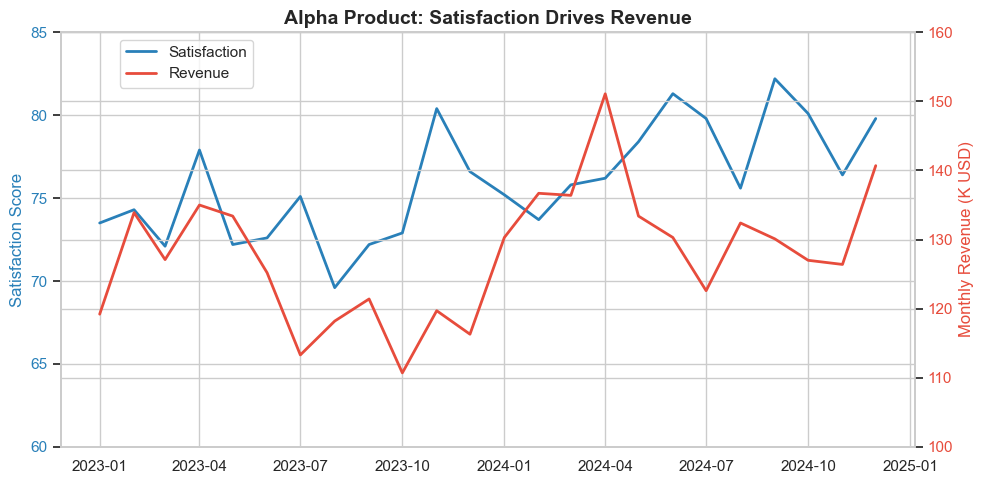

In [7]:
alpha = df[df["product"] == "Alpha"].set_index("month")

fig, ax1 = plt.subplots(figsize=(10, 5))

color_left = "#2980b9"
ax1.plot(alpha.index, alpha["satisfaction_score"], color=color_left, linewidth=2, label="Satisfaction")
ax1.set_ylabel("Satisfaction Score", color=color_left, fontsize=12)
ax1.set_ylim(60, 85)
ax1.tick_params(axis="y", labelcolor=color_left)

ax2 = ax1.twinx()
color_right = "#e74c3c"
ax2.plot(alpha.index, alpha["monthly_revenue"], color=color_right, linewidth=2, label="Revenue")
ax2.set_ylabel("Monthly Revenue (K USD)", color=color_right, fontsize=12)
ax2.set_ylim(100, 160)
ax2.tick_params(axis="y", labelcolor=color_right)

ax1.set_title("Alpha Product: Satisfaction Drives Revenue", fontsize=14, fontweight="bold")
fig.legend(loc="upper left", bbox_to_anchor=(0.12, 0.92))
plt.tight_layout()
plt.show()

**Your critique of Chart 2:**

*TODO: Write your analysis here — identify the deception, explain the misleading message, and quantify the distortion.*

**Explanation:**
Satisfaction and Revenue are plotted on two separate Y-axes with different scales, carefully adjusted so that the lines appear to move together. This creates the illusion of a strong correlation, misleading viewers into believing that satisfaction directly drives revenue, even if no such relationship exists.

**Distortion Estimate:**
By manipulating the starting and ending points of each axis, the trends are artificially synchronized, making unrelated patterns appear correlated.

### Misleading Chart 3 — Cherry-Picked Time Range

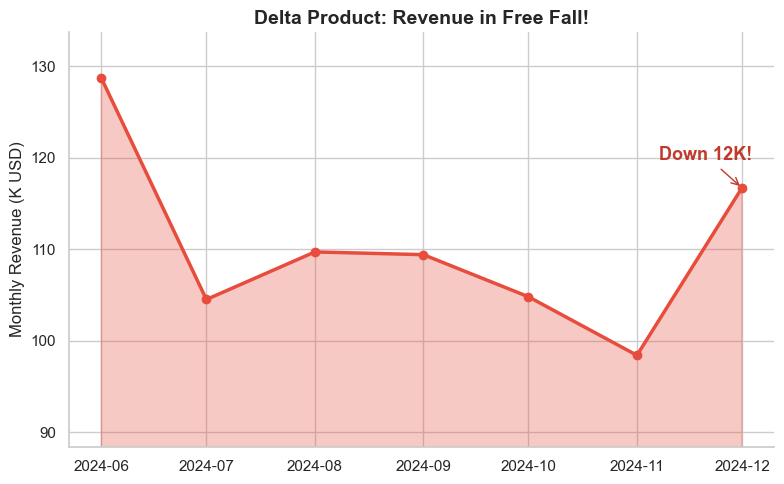

In [8]:
delta = df[df["product"] == "Delta"].set_index("month")
cherry = delta.loc["2024-06":"2024-12"]

fig, ax = plt.subplots(figsize=(8, 5))
ax.fill_between(cherry.index, cherry["monthly_revenue"], alpha=0.3, color="#e74c3c")
ax.plot(cherry.index, cherry["monthly_revenue"], color="#e74c3c", linewidth=2.5, marker="o")
ax.set_ylabel("Monthly Revenue (K USD)", fontsize=12)
ax.set_title("Delta Product: Revenue in Free Fall!", fontsize=14, fontweight="bold")
ax.set_ylim(cherry["monthly_revenue"].min() - 10, cherry["monthly_revenue"].max() + 5)

ax.annotate(f"Down {cherry['monthly_revenue'].iloc[0] - cherry['monthly_revenue'].iloc[-1]:.0f}K!",
            xy=(cherry.index[-1], cherry["monthly_revenue"].iloc[-1]),
            fontsize=13, fontweight="bold", color="#c0392b",
            xytext=(-60, 20), textcoords="offset points",
            arrowprops=dict(arrowstyle="->", color="#c0392b"))

sns.despine()
plt.tight_layout()
plt.show()

**Your critique of Chart 3:**

*TODO: Write your analysis here — identify the deception, explain the misleading message, and quantify the distortion.*

**Explanation:**
The chart only displays data from the second half of 2024, creating the impression that revenue is sharply declining. However, this is just a segment of a seasonal fluctuation built into the data. When the full time range is considered, the overall trend may look very different.

**Distortion Estimate:**
Only 7 months of data are shown, while the full 24-month period is omitted, hiding the broader upward trend.

---

## Task 2: Chart Redesign — Fix the Story

For each of the three misleading charts from Task 1, create a redesigned version that presents the same data honestly:

1. Use an appropriate chart type and axis range.
2. Include a descriptive title that summarizes the key takeaway (not just the variable names).
3. Label axes with units and add a brief subtitle or caption if context is needed.
4. Use color intentionally — highlight comparisons, don't just decorate.

**Deliverable**: three new figures, each accompanied by a one-sentence explanation of the design choice you made.

### Redesign 1 — Fixing the Truncated Y-Axis Chart

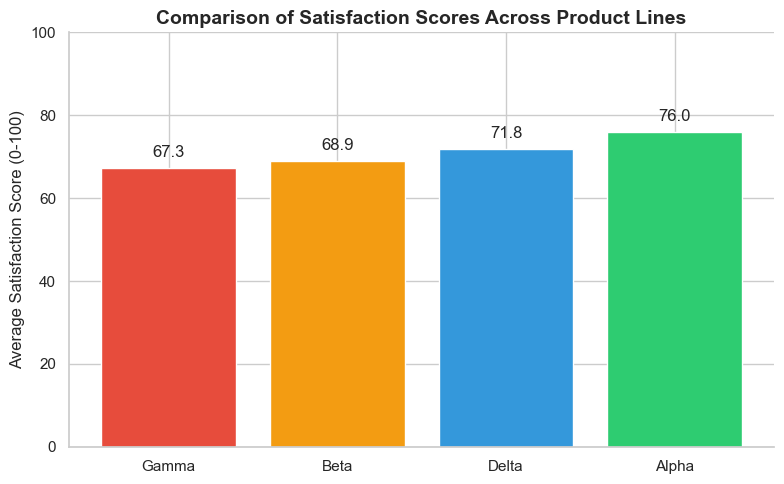

In [9]:
# TODO: Create your redesigned version of Chart 1
# Hints:
#   - Start the y-axis at 0 to show the true proportions
#   - Use a descriptive title that summarizes the actual finding
#   - Consider whether a bar chart is still the best choice


avg_sat = df.groupby("product")["satisfaction_score"].mean().sort_values()

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(avg_sat.index, avg_sat.values, color=["#e74c3c", "#f39c12", "#3498db", "#2ecc71"])

ax.set_ylim(0, 100) 
ax.set_ylabel("Average Satisfaction Score (0-100)")
ax.set_title("Comparison of Satisfaction Scores Across Product Lines", fontsize=14, fontweight="bold")


for bar in bars:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 2,
            f"{bar.get_height():.1f}", ha="center", va="bottom")

sns.despine()
plt.tight_layout()
plt.show()

**Design choice explanation:**

*By starting the y-axis at 0, I honestly demonstrated that the real difference between products is small and that all products perform well overall.*

### Redesign 2 — Fixing the Dual-Axis Chart

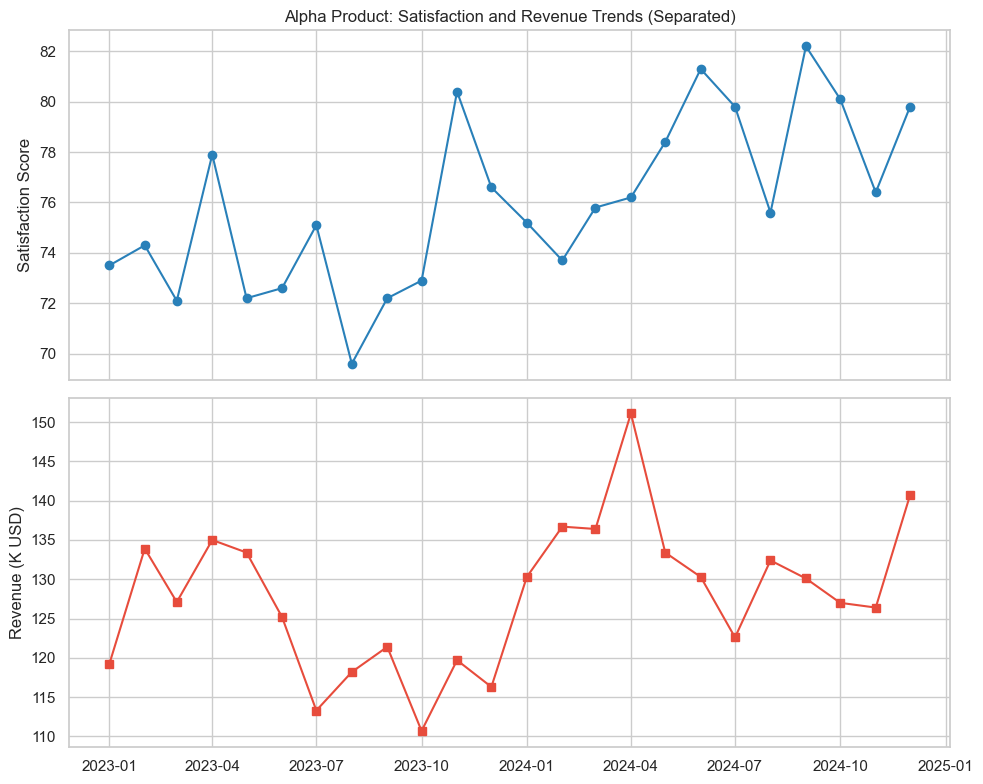

In [10]:
# TODO: Create your redesigned version of Chart 2
# Hints:
#   - Consider using two separate panels instead of overlapping axes
#   - If claiming a relationship, compute and show the actual correlation
#   - Normalize or use a shared scale if comparison is the goal

# Redesign 2: İki fərqli panel istifadə edərək trendləri ayırmaq
alpha = df[df["product"] == "Alpha"]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# Panel 1: Satisfaction
ax1.plot(alpha["month"], alpha["satisfaction_score"], color="#2980b9", marker='o')
ax1.set_ylabel("Satisfaction Score")
ax1.set_title("Alpha Product: Satisfaction and Revenue Trends (Separated)")

# Panel 2: Revenue
ax2.plot(alpha["month"], alpha["monthly_revenue"], color="#e74c3c", marker='s')
ax2.set_ylabel("Revenue (K USD)")

plt.tight_layout()
plt.show()

**Design choice explanation:**

*TODO: Write one sentence explaining the key design decision you made and why.*

Design choice explanation: I separated the variables by using two different subplots so that the viewer can follow both trends independently without being fooled by artificial visual overlaps.

### Redesign 3 — Fixing the Cherry-Picked Time Range Chart

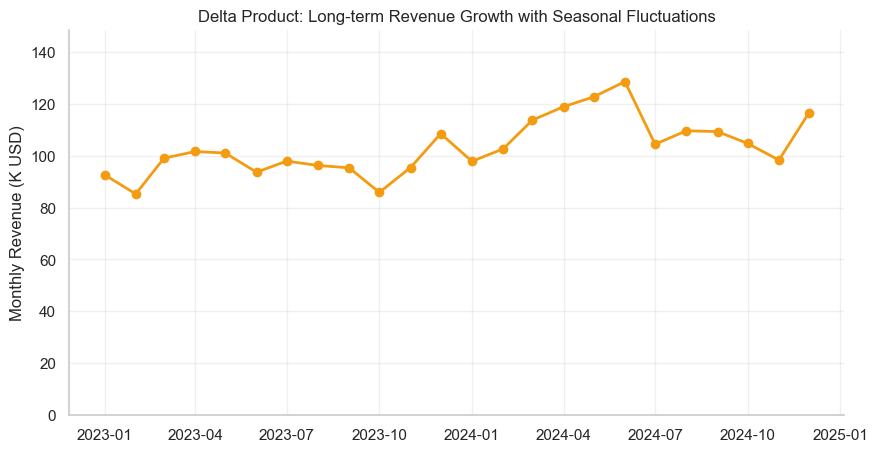

In [13]:
delta = df[df["product"] == "Delta"]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(delta["month"], delta["monthly_revenue"], color="#f39c12", linewidth=2, marker='o')

ax.set_ylim(0, delta["monthly_revenue"].max() + 20) 
ax.set_ylabel("Monthly Revenue (K USD)")
ax.set_title("Delta Product: Long-term Revenue Growth with Seasonal Fluctuations")

plt.grid(True, alpha=0.3)
sns.despine()
plt.show()

**Design choice explanation:**

*TODO: Write one sentence explaining the key design decision you made and why.*

Design choice explanation: By showing the entire 24 months of data, I proved that the short-term decline is actually part of the annual seasonal trend and that the overall direction is still positive.

---

## Task 3: Three-Panel Visual Report

Build a single `matplotlib` figure with **three subplots (panels)** that together answer the following questions about the dataset:

1. **Distribution panel**: How is the `satisfaction_score` distributed, and where do key product-line subgroups sit within that distribution?
2. **Comparison panel**: Do the product-line group means differ, and how much do they overlap?
3. **Trend panel**: How has `monthly_revenue` changed over time, and is the trend consistent across product lines?

**Requirements for each panel:**
- A clear, specific title (not "Plot 1").
- Axis labels with units.
- A legend if multiple groups are shown.
- Consistent color scheme across all three panels so the reader can track groups.

**Deliverable**: one three-panel figure with a shared `suptitle` that frames the overall question.

In [ ]:
# Color palette to use consistently across all three panels
palette = {"Alpha": "#3498db", "Beta": "#e74c3c", "Gamma": "#2ecc71", "Delta": "#f39c12"}

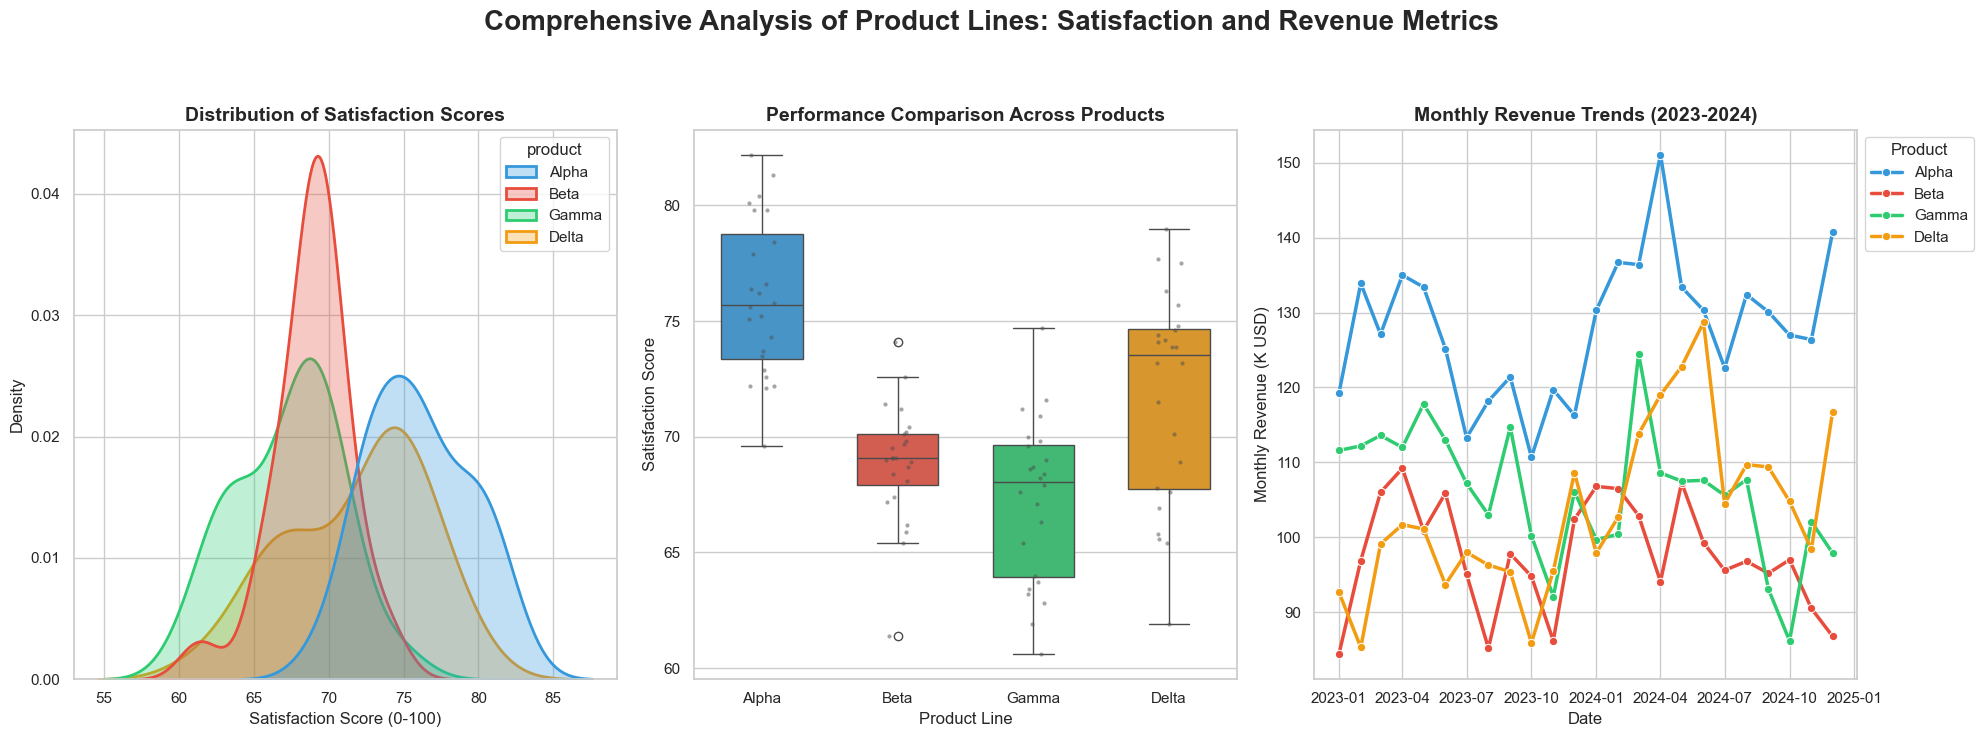

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# Color palette for products
palette = {"Alpha": "#3498db", "Beta": "#e74c3c", "Gamma": "#2ecc71", "Delta": "#f39c12"}

# Create figure with 3 panels
fig, axes = plt.subplots(1, 3, figsize=(20, 7))

# --- Panel 1: Distribution ---
# KDE plot shows the density distribution of satisfaction scores
sns.kdeplot(
    data=df,
    x="satisfaction_score",
    hue="product",
    palette=palette,
    fill=True,
    alpha=0.3,
    linewidth=2,
    ax=axes[0]
)
axes[0].set_title("Distribution of Satisfaction Scores", fontsize=14, fontweight="bold")
axes[0].set_xlabel("Satisfaction Score (0-100)")
axes[0].set_ylabel("Density")

# --- Panel 2: Comparison ---
# Box plot compares products 
sns.boxplot(
    data=df,
    x="product",
    y="satisfaction_score",
    hue="product",        
    palette=palette,
    ax=axes[1],
    width=0.6,
    legend=False          
)

# Add individual data points
sns.stripplot(
    data=df,
    x="product",
    y="satisfaction_score",
    color=".3",
    size=3,
    alpha=0.5,
    ax=axes[1]
)

axes[1].set_title("Performance Comparison Across Products", fontsize=14, fontweight="bold")
axes[1].set_xlabel("Product Line")
axes[1].set_ylabel("Satisfaction Score")

# --- Panel 3: Trend (Time Series) ---
# Line plot shows revenue changes over time
sns.lineplot(
    data=df,
    x="month",
    y="monthly_revenue",
    hue="product",
    palette=palette,
    linewidth=2.5,
    marker='o',
    markersize=6,
    ax=axes[2]
)

axes[2].set_title("Monthly Revenue Trends (2023-2024)", fontsize=14, fontweight="bold")
axes[2].set_xlabel("Date")
axes[2].set_ylabel("Monthly Revenue (K USD)")
axes[2].legend(title="Product", loc='upper left', bbox_to_anchor=(1, 1))

# Overall title
fig.suptitle(
    "Comprehensive Analysis of Product Lines: Satisfaction and Revenue Metrics",
    fontsize=20,
    fontweight="bold",
    y=1.05
)

# Adjust layout
plt.tight_layout()

# Show plot
plt.show()

---

## Bonus: Peer Review Checklist

If working with a partner, swap notebooks and evaluate their visualizations using this checklist:

| Criterion | Yes / No | Notes |
|---|---|---|
| Y-axis starts at zero (or a break is clearly marked) | | |
| Title describes the finding, not just the variables | | |
| Axes are labeled with units | | |
| Color is used to encode meaning, not decoration | | |
| Uncertainty is shown where relevant (error bars, bands) | | |
| The chart can be understood without a verbal walkthrough | | |
| No chart junk (unnecessary gridlines, 3D effects, etc.) | | |